# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Inida Tech Job Market Dataset](https://www.kaggle.com/datasets/sridipbasu/india-tech-jobs-2024-2026-salary-and-skills)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('india_job_market_2024_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


## last Five row

In [4]:
df.tail()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
4995,IND2029995,Backend Developer,BEL,PSU/Govt,Media & Entertainment,Jaipur,Tier 2,Fresher (0-1 yr),Full-Time,Hybrid,4.5,"PostgreSQL, Java, Django, MongoDB, Docker",B.Tech/B.E.,2,72,4.2,2025-03-11
4996,IND2029996,React Developer,Google,MNC,Manufacturing,Remote,Remote,Fresher (0-1 yr),Full-Time,Remote,4.3,"TypeScript, React, JavaScript, Redux, Next.js",B.Tech/B.E.,1,76,4.0,2024-12-30
4997,IND2029997,QA Engineer,BHEL,PSU/Govt,FinTech,Remote,Remote,Mid (3-6 yrs),Contract,Remote,10.5,"Python, API Testing, Manual Testing, JIRA",B.Tech/B.E.,2,72,3.1,2026-02-23
4998,IND2029998,Frontend Developer,Byju's,Indian Unicorn,FinTech,Remote,Remote,Mid (3-6 yrs),Internship,On-Site,1.6,"Tailwind CSS, Figma, React, JavaScript, TypeSc...",BCA,3,187,3.9,2025-04-26
4999,IND2029999,Power BI Developer,PhonePe,Indian Unicorn,Manufacturing,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,On-Site,25.2,"ETL, Azure, Power BI",B.Tech/B.E.,1,110,4.3,2025-08-13


## Shape of our dataset

In [5]:
df.shape

(5000, 17)

## List out all columns

In [6]:
df.columns

Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Job_ID                 object
Job_Title              object
Company                object
Company_Type           object
Industry               object
City                   object
Location_Tier          object
Experience_Level       object
Job_Type               object
Work_Mode              object
Salary_LPA            float64
Skills_Required        object
Education_Required     object
Openings                int64
Applicants              int64
Company_Rating        float64
Date_Posted            object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

## Check Null Value

In [9]:
df.isnull().sum()

Job_ID                0
Job_Title             0
Company               0
Company_Type          0
Industry              0
City                  0
Location_Tier         0
Experience_Level      0
Job_Type              0
Work_Mode             0
Salary_LPA            0
Skills_Required       0
Education_Required    0
Openings              0
Applicants            0
Company_Rating        0
Date_Posted           0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Salary_LPA,Openings,Applicants,Company_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.829440,3.642600,302.072000,3.698420
std,18.136741,4.046942,363.989613,0.424994
min,0.800000,1.000000,14.000000,2.500000
25%,6.800000,1.000000,99.000000,3.400000
50%,13.600000,2.000000,185.000000,3.800000
75%,25.600000,3.000000,321.000000,4.100000
max,115.400000,20.000000,2387.000000,4.300000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

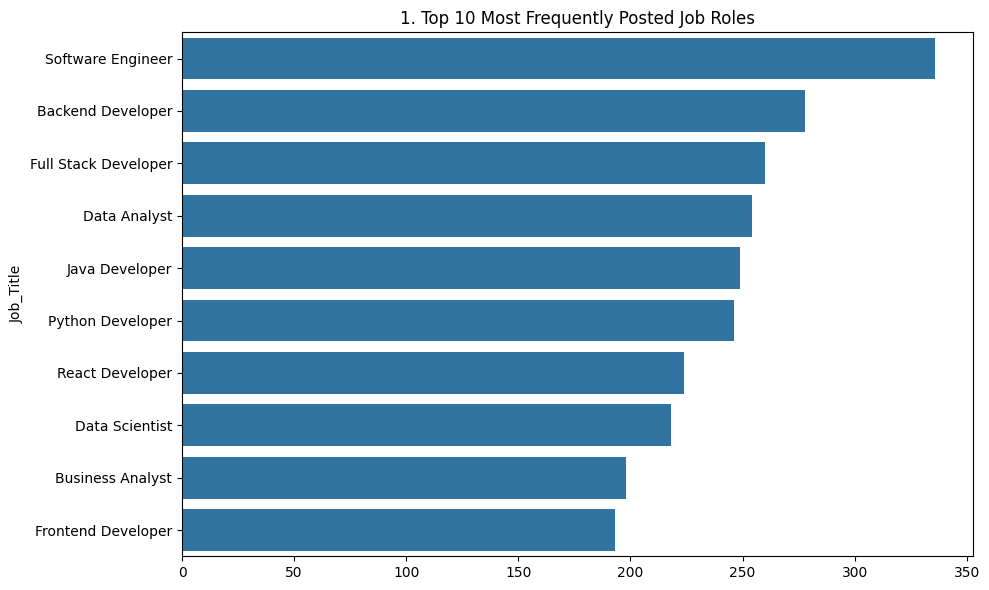

In [13]:
fig = plt.figure(figsize=(10,6))
top_jobs = df['Job_Title'].value_counts().head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index)
plt.title(f'{plot_no}. Top 10 Most Frequently Posted Job Roles')
show_fig()
plot_no += 1

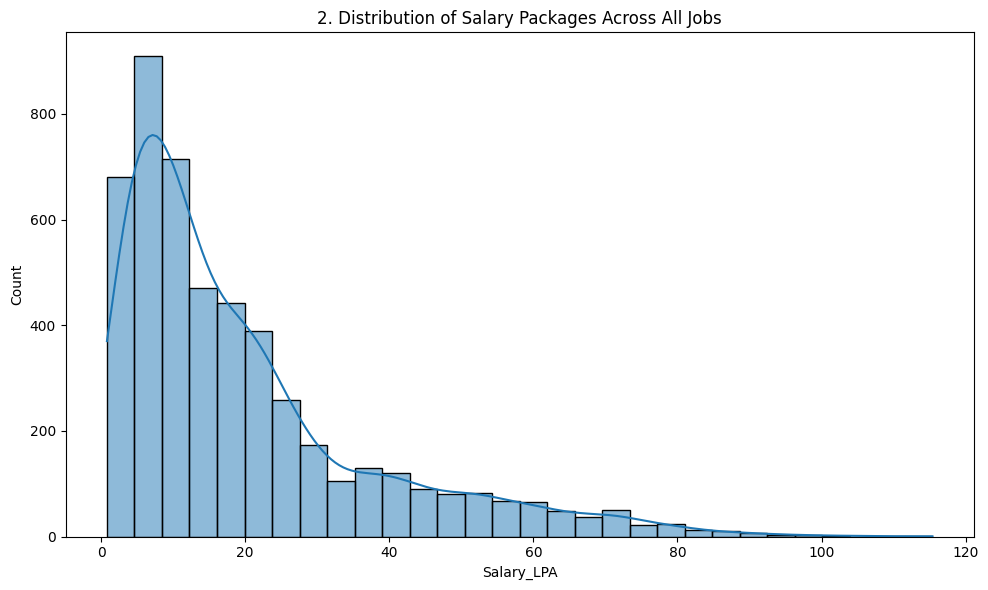

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Salary_LPA'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Salary Packages Across All Jobs')
show_fig()
plot_no += 1

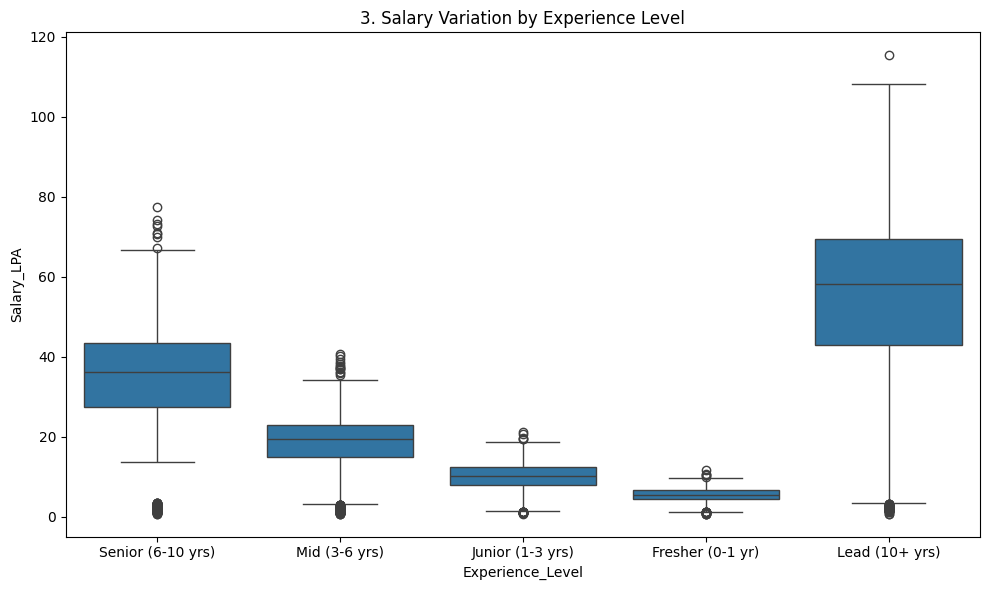

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Experience_Level', y='Salary_LPA', data=df)
plt.title(f'{plot_no}. Salary Variation by Experience Level')
show_fig()
plot_no += 1

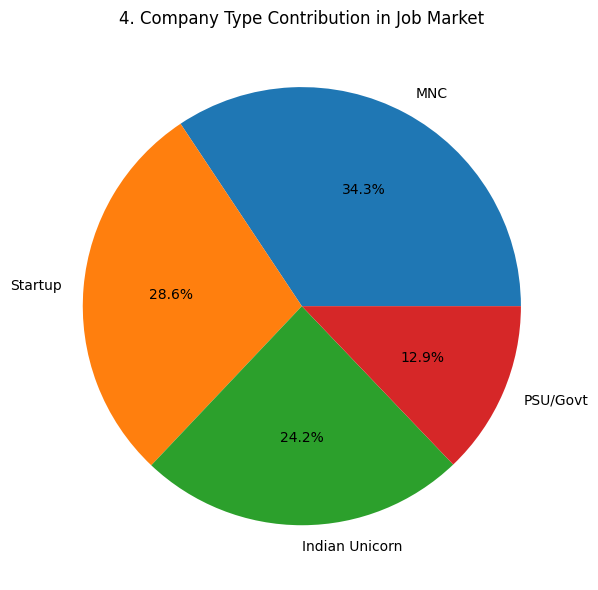

In [16]:
fig = plt.figure(figsize=(10,6))
company_counts = df['Company_Type'].value_counts()
plt.pie(company_counts.values, labels=company_counts.index, autopct='%1.1f%%')
plt.title(f'{plot_no}. Company Type Contribution in Job Market')
show_fig()
plot_no += 1

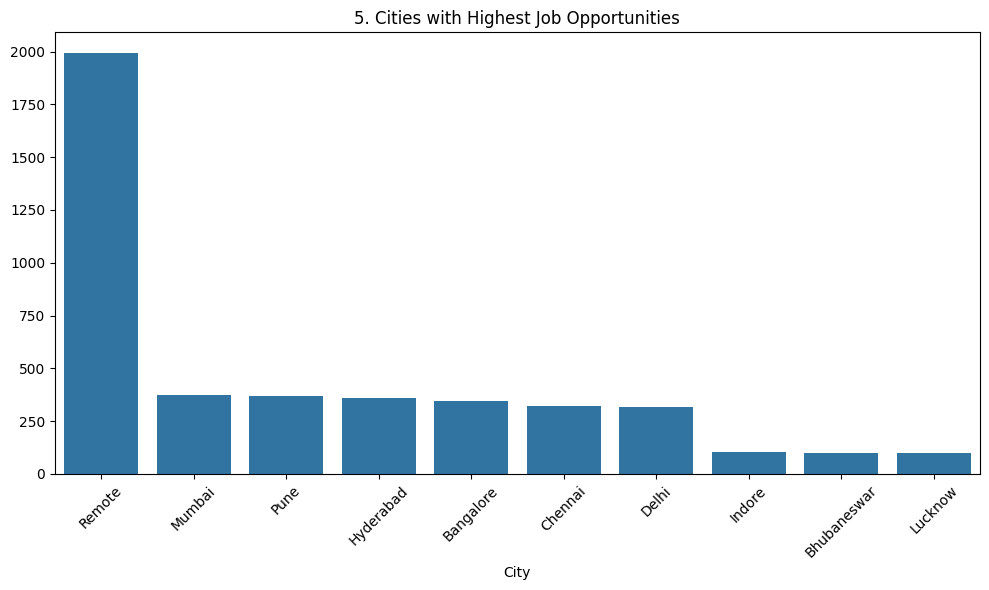

In [17]:
fig = plt.figure(figsize=(10,6))
top_cities = df['City'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Cities with Highest Job Opportunities')
show_fig()
plot_no += 1

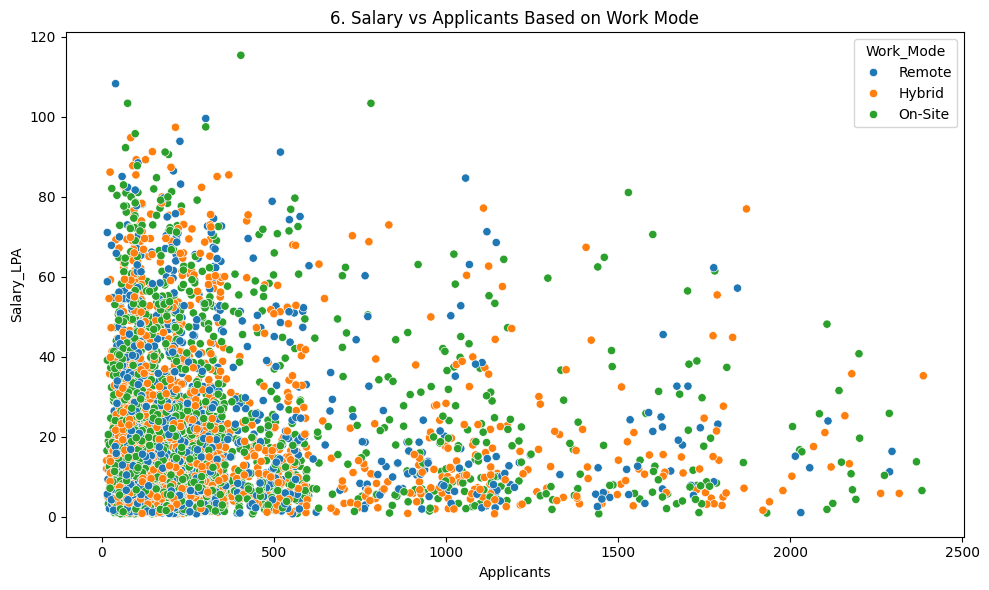

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Applicants', y='Salary_LPA', hue='Work_Mode', data=df)
plt.title(f'{plot_no}. Salary vs Applicants Based on Work Mode')
show_fig()
plot_no += 1

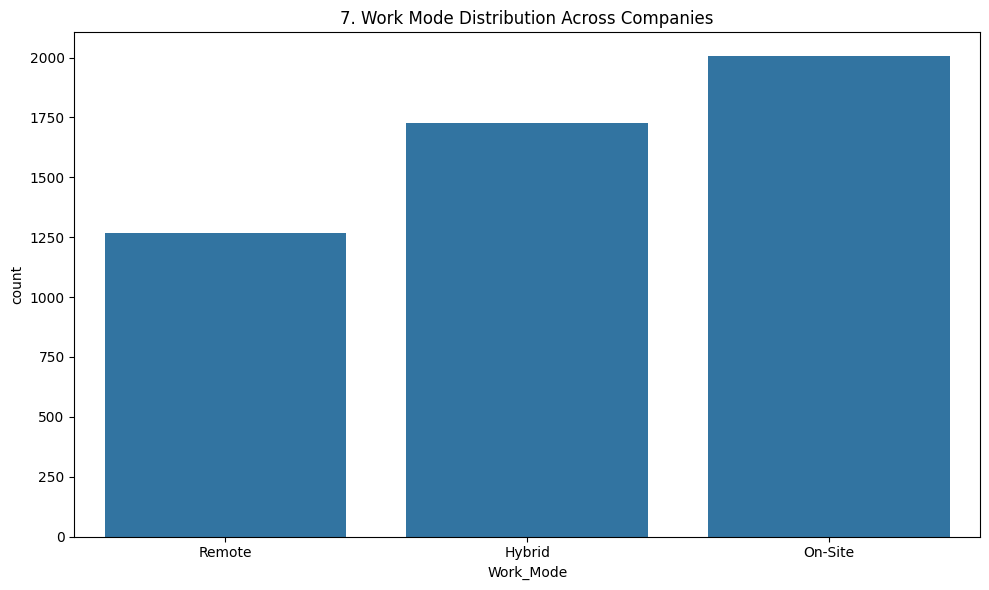

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Work_Mode', data=df)
plt.title(f'{plot_no}. Work Mode Distribution Across Companies')
show_fig()
plot_no += 1

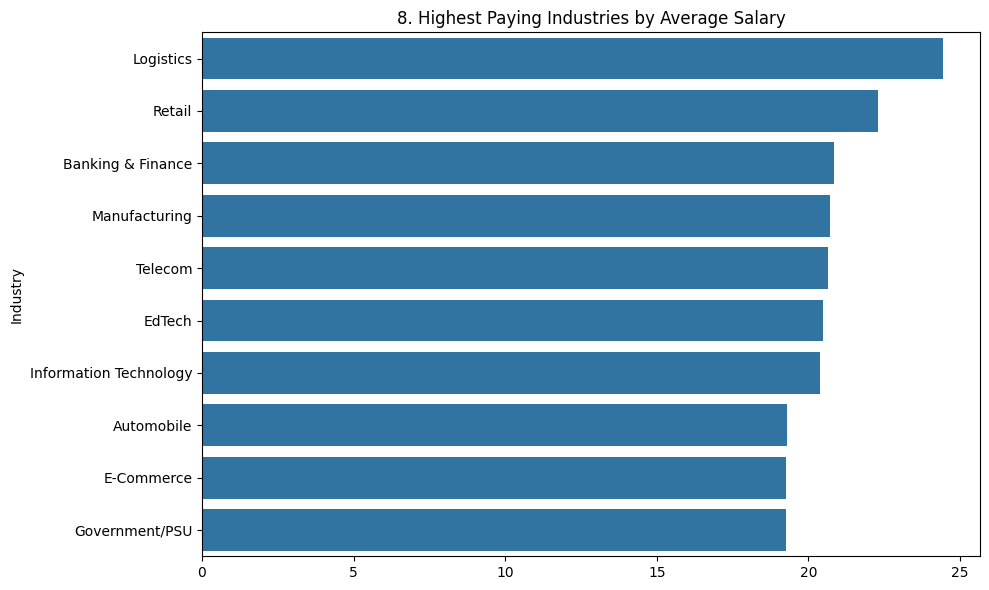

In [20]:
fig = plt.figure(figsize=(10,6))
industry_salary = df.groupby('Industry')['Salary_LPA'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=industry_salary.values, y=industry_salary.index)
plt.title(f'{plot_no}. Highest Paying Industries by Average Salary')
show_fig()
plot_no += 1

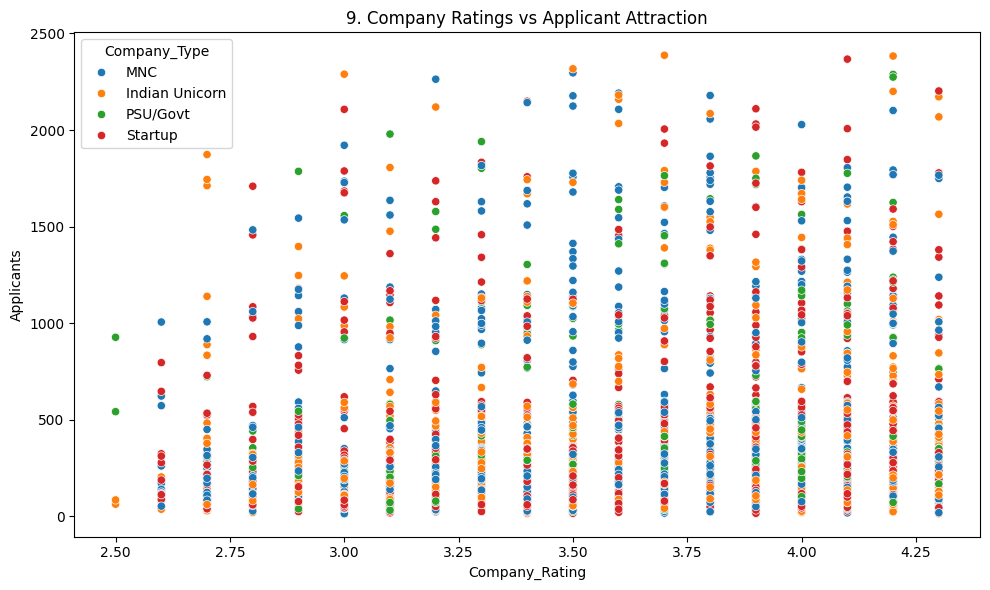

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Company_Rating', y='Applicants', hue='Company_Type', data=df)
plt.title(f'{plot_no}. Company Ratings vs Applicant Attraction')
show_fig()
plot_no += 1

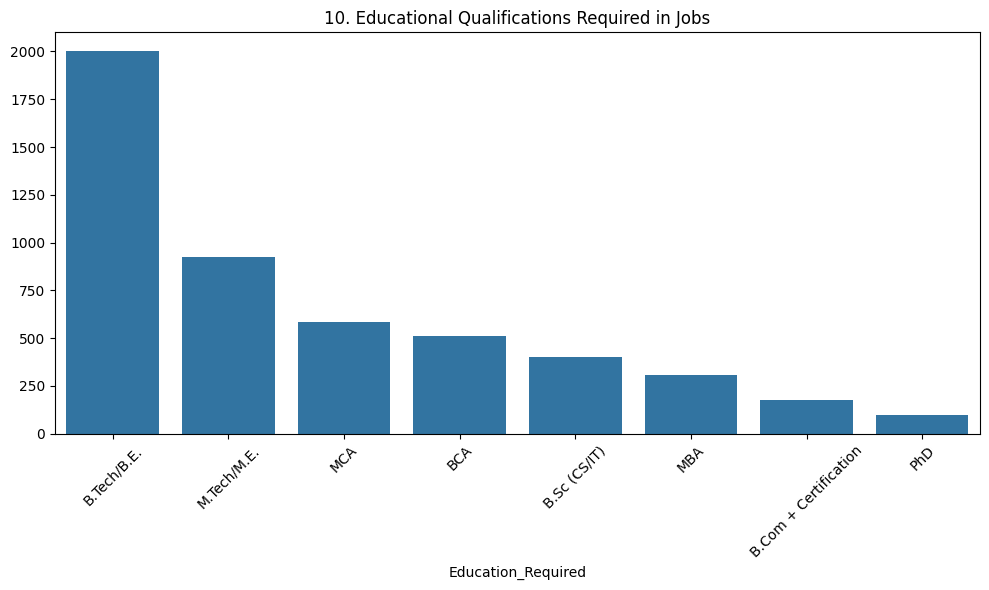

In [22]:
fig = plt.figure(figsize=(10,6))
education_counts = df['Education_Required'].value_counts()
sns.barplot(x=education_counts.index, y=education_counts.values)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Educational Qualifications Required in Jobs')
show_fig()
plot_no += 1

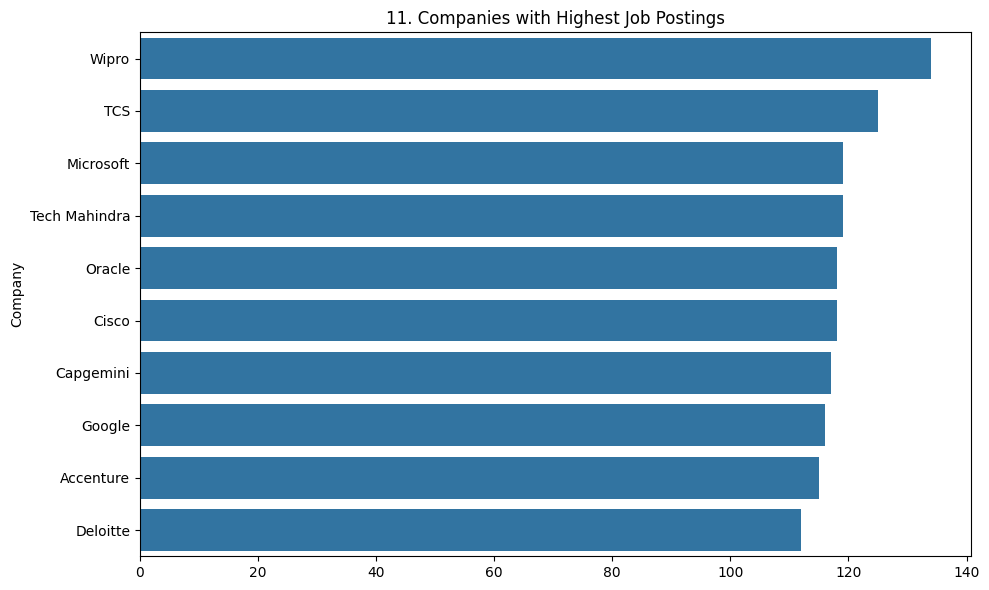

In [23]:
fig = plt.figure(figsize=(10,6))
top_companies = df['Company'].value_counts().head(10)
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title(f'{plot_no}. Companies with Highest Job Postings')
show_fig()
plot_no += 1

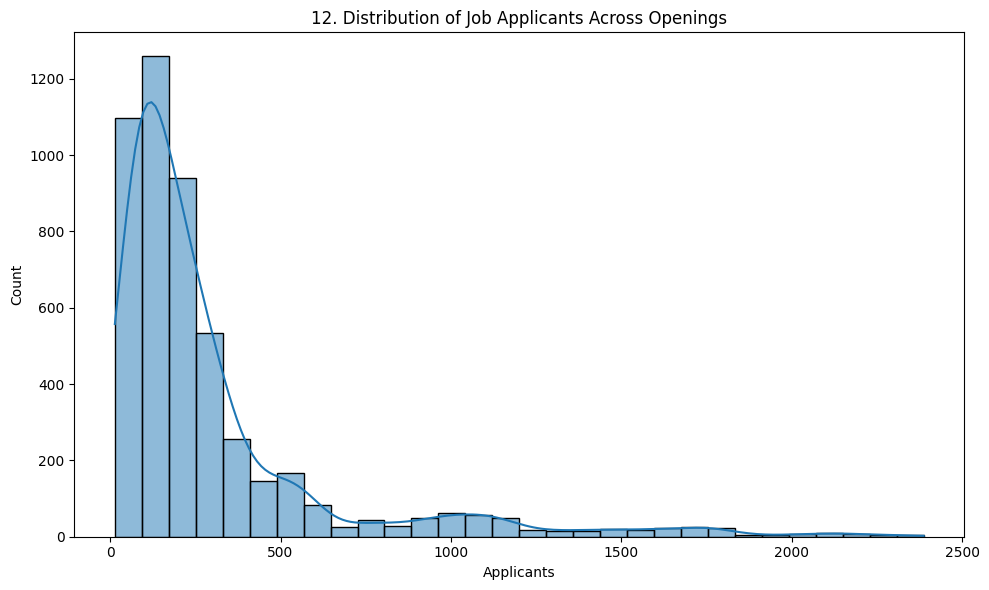

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Applicants'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Job Applicants Across Openings')
show_fig()
plot_no += 1

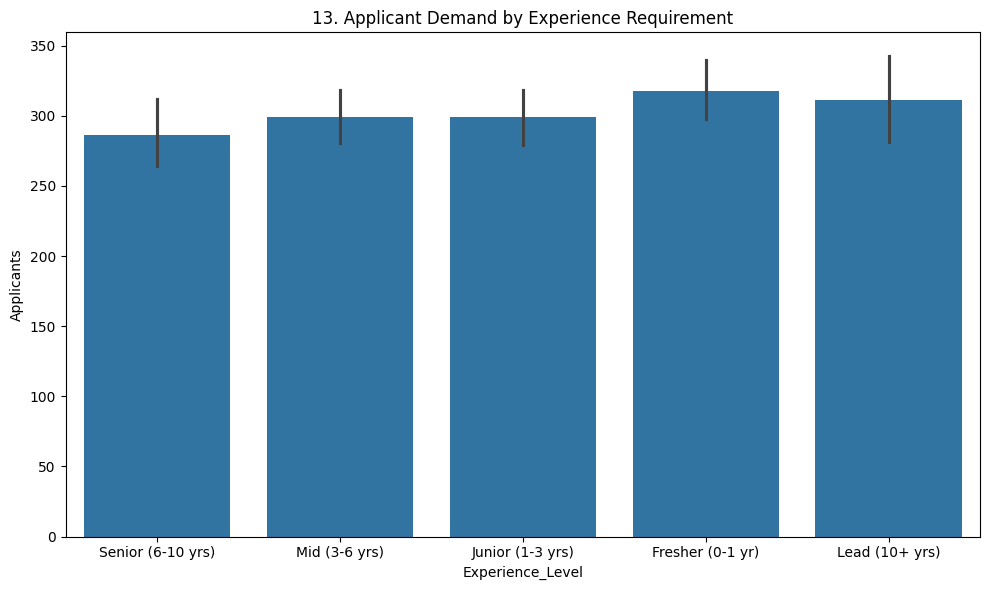

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Experience_Level', y='Applicants', data=df)
plt.title(f'{plot_no}. Applicant Demand by Experience Requirement')
show_fig()
plot_no += 1

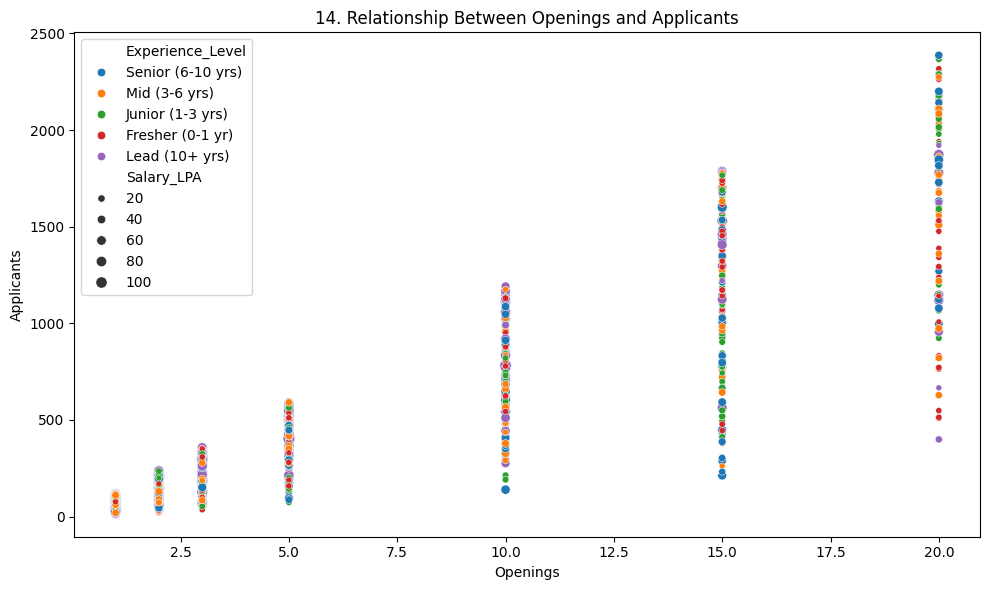

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Openings', y='Applicants', size='Salary_LPA', hue='Experience_Level', data=df)
plt.title(f'{plot_no}. Relationship Between Openings and Applicants')
show_fig()
plot_no += 1

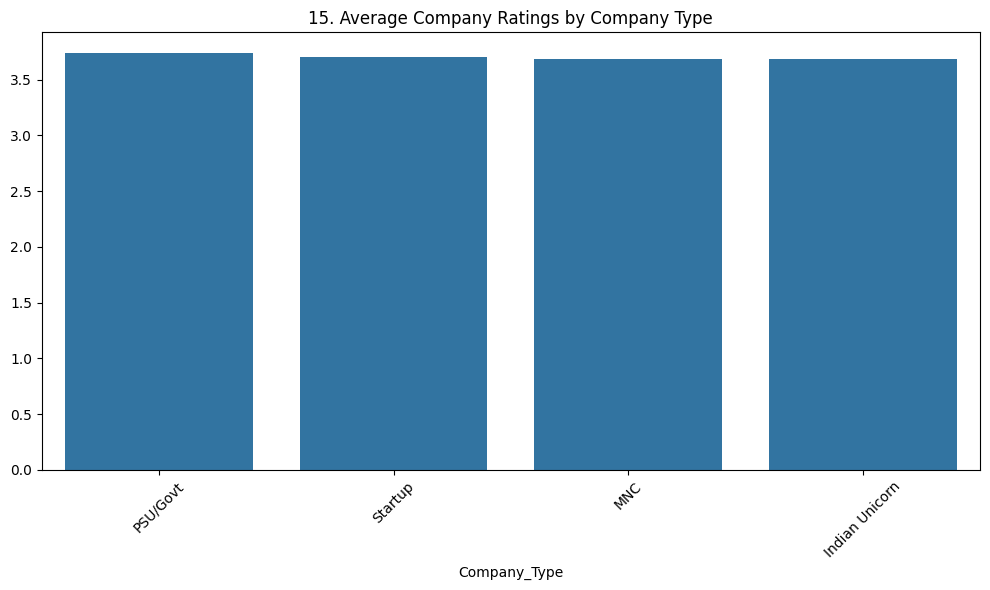

In [27]:
fig = plt.figure(figsize=(10,6))
avg_rating = df.groupby('Company_Type')['Company_Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.index, y=avg_rating.values)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Company Ratings by Company Type')
show_fig()
plot_no += 1

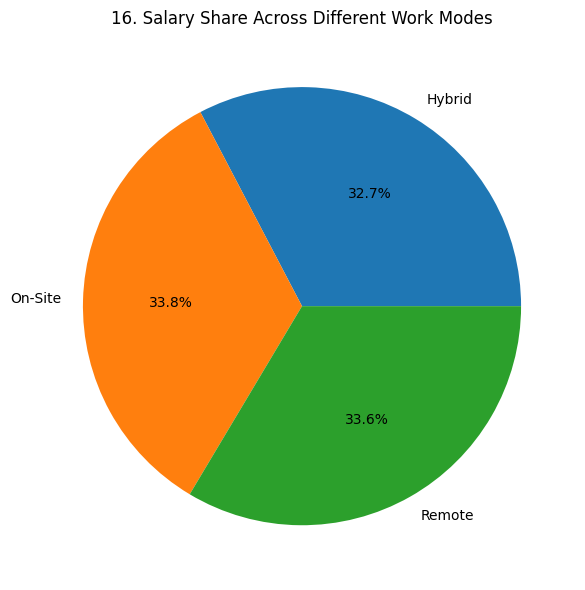

In [28]:
fig = plt.figure(figsize=(10,6))
salary_workmode = df.groupby('Work_Mode')['Salary_LPA'].mean()
plt.pie(salary_workmode.values, labels=salary_workmode.index, autopct='%1.1f%%')
plt.title(f'{plot_no}. Salary Share Across Different Work Modes')
show_fig()
plot_no += 1

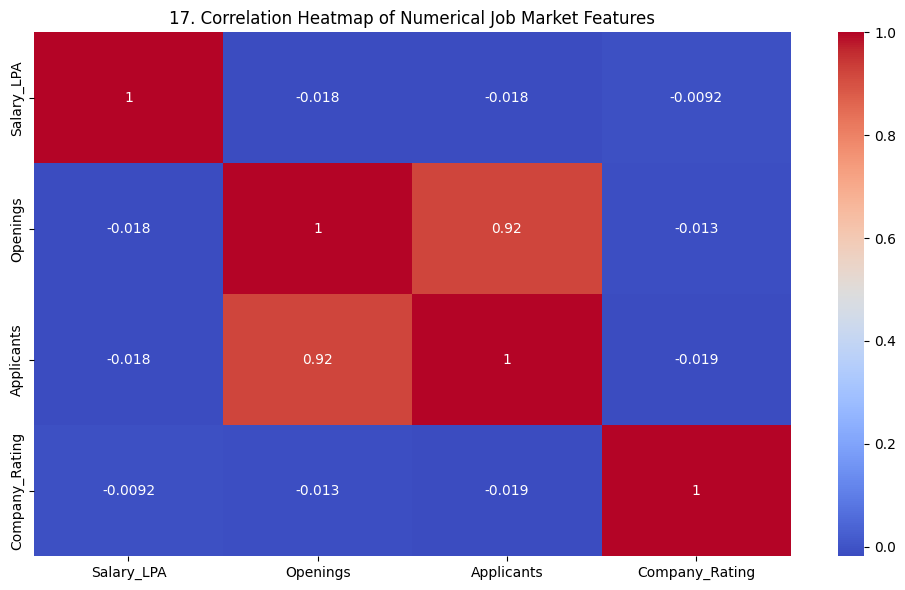

In [29]:
fig = plt.figure(figsize=(10,6))
corr = df[['Salary_LPA', 'Openings', 'Applicants', 'Company_Rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Job Market Features')
show_fig()
plot_no += 1

# Model Training

## create salary category target

In [30]:
df['Salary_Category'] = pd.cut(
    df['Salary_LPA'],
    bins=[0, 15, 30, 100],
    labels=['Low', 'Medium', 'High']
)

## remove rows where target contains NaN

In [31]:
df = df.dropna(subset=['Salary_Category'])

## define features and target

In [32]:
X = df.drop(['Job_ID', 'Salary_LPA', 'Salary_Category'], axis=1)
y = df['Salary_Category']

## encode categorical columns

In [33]:
label_encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

## fill missing values in features

In [34]:
imputer = SimpleImputer(strategy='most_frequent')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

## split dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## scale numerical features

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train supervised model

In [37]:
model = SVC(kernel='rbf')

model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## predict values

In [38]:
y_pred = model.predict(X_test)

## print model performance

In [39]:
print("Accuracy Score :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy Score : 0.749

Classification Report

              precision    recall  f1-score   support

        High       0.67      0.30      0.42       201
         Low       0.87      0.91      0.89       536
      Medium       0.58      0.75      0.65       263

    accuracy                           0.75      1000
   macro avg       0.70      0.66      0.65      1000
weighted avg       0.75      0.75      0.73      1000



## create confusion matrix

In [40]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

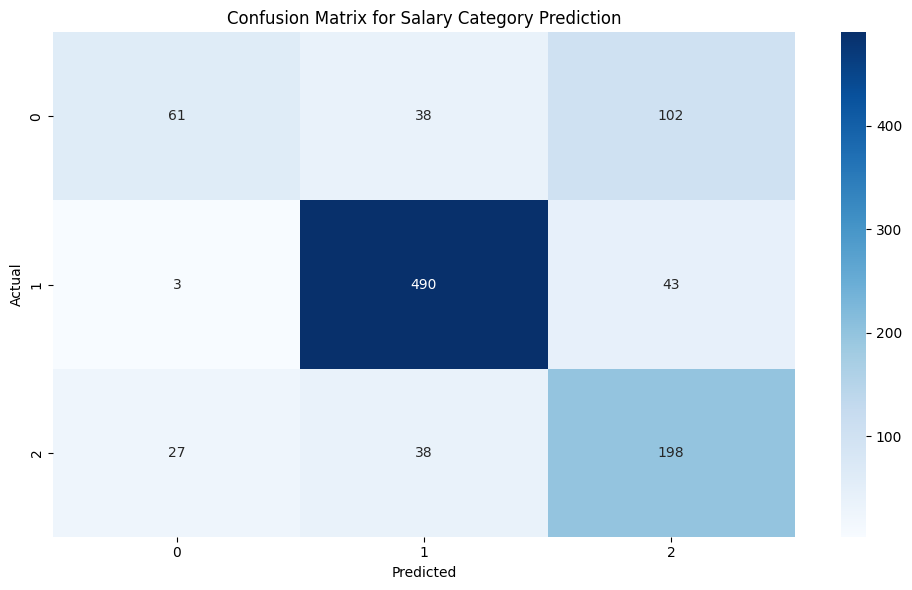

In [41]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Salary Category Prediction')
plt.tight_layout()
plt.show()